# From one prediction to an LLM behavioral model

**Progressive hands-on notebook / DeepSeek API / anonymized individual-level risky-choice data**

We will reuse one measurement all the way through:

1. hide one participant's choice;
2. ask the model to predict **A or B**;
3. inspect the model's top-token **log probabilities**;
4. re-normalize probability mass over the valid labels `{A, B}`;
5. reveal the human choice and compute log loss;
6. repeat while increasing the number of earlier choices in context.

The last step turns a vivid example into a behavioral-model evaluation. More examples are a hypothesis, not a guarantee of improvement.

## 0. Setup

The notebook runs on Colab or an ordinary laptop because inference is an API call. Put `DEEPSEEK_API_KEY=...` in the project `.env`, set it as an environment variable, or add it to Colab Secrets. The notebook never prints the key.

In [1]:
# Uncomment in a fresh Colab runtime.
# %pip install -q openai pandas numpy matplotlib scikit-learn

In [2]:
from pathlib import Path
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI

MODEL = "deepseek-v4-flash"
BASE_URL = "https://api.deepseek.com"
SEED = 3000
pd.set_option("display.max_colwidth", 110)
plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
def find_file(relative_path):
    relative_path = Path(relative_path)
    candidates = [
        relative_path,
        Path("notebooks") / relative_path,
        Path("/content") / relative_path,
        Path("/content/LLM_human_decisions/notebooks") / relative_path,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {relative_path}")


def load_dotenv_without_extra_package():
    candidates = [Path(".env"), Path("../.env"), Path("../../.env")]
    for path in candidates:
        if path.exists():
            for line in path.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if line and not line.startswith("#") and "=" in line:
                    key, value = line.split("=", 1)
                    os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))
            return path
    return None


env_path = load_dotenv_without_extra_package()
api_key = os.getenv("DEEPSEEK_API_KEY")
client = OpenAI(api_key=api_key, base_url=BASE_URL) if api_key else None
print("DeepSeek key available:", bool(api_key))
print("Loaded .env from:", env_path if env_path else "environment / Colab secret / not found")

DeepSeek key available: True
Loaded .env from: ..\.env


In [4]:
DATA_PATH = find_file("data/behavioral_expanded_public_slice.csv")
data = pd.read_csv(DATA_PATH)

assert data["participant_id"].nunique() == 32
assert data.groupby("participant_id").size().eq(40).all()
assert set(data["choice"]) <= {"A", "B"}

print(f"Loaded {len(data):,} rows: {data['participant_id'].nunique()} participants x 40 ordered trials")
print("Public slice excludes raw IDs, language, RT, and other unnecessary fields.")

Loaded 1,280 rows: 32 participants x 40 ordered trials
Public slice excludes raw IDs, language, RT, and other unnecessary fields.


## 1. Begin with one real held-out choice

We use anonymized participant `P025`, trial 21. Trials 1-20 are earlier in time and therefore eligible as history; the target choice stays hidden until scoring.

In [5]:
participant_id = "P025"
target_trial = 21
target = data.query(
    "participant_id == @participant_id and trial_index == @target_trial"
).iloc[0]

print("Participant screen")
print("------------------")
print("Option A:", target["lottery_A"])
print("Option B:", target["lottery_B"])
print("Observed choice: [HIDDEN]")

Participant screen
------------------
Option A: 75% chance of -16; 25% chance of 40
Option B: -3 for sure
Observed choice: [HIDDEN]


In [6]:
def make_messages(target_row, history=None):
    history = history if history is not None else pd.DataFrame()
    history_text = ""
    if len(history):
        examples = []
        for _, row in history.iterrows():
            examples.append(
                f"Earlier trial {int(row['trial_index'])}:\n"
                f"Option A: {row['lottery_A']}\n"
                f"Option B: {row['lottery_B']}\n"
                f"Observed choice: {row['choice']}"
            )
        history_text = (
            "Here are earlier choices from the same participant:\n\n"
            + "\n\n".join(examples)
            + "\n\n"
        )

    return [
        {"role": "system", "content": "Answer with exactly one token: A or B."},
        {
            "role": "user",
            "content": (
                history_text
                + "Predict this participant's choice on a new trial.\n"
                + f"Option A: {target_row['lottery_A']}\n"
                + f"Option B: {target_row['lottery_B']}\n"
                + "Answer:"
            ),
        },
    ]


zero_shot_messages = make_messages(target)
print(zero_shot_messages[1]["content"])

Predict this participant's choice on a new trial.
Option A: 75% chance of -16; 25% chance of 40
Option B: -3 for sure
Answer:


## 2. Ask for the label *and* top-token logprobs

Set `temperature=1` so the returned logprobs stay on the model's natural scale. The generated `A` or `B` is one sample; the probability estimate comes from the candidate-label logprobs.

DeepSeek returns logprobs for token surface forms. `"A"` and `" A"` can be different tokens, even though both mean label A after whitespace normalization.

In [7]:
def call_label_logprobs(messages):
    if client is None:
        raise RuntimeError("Set DEEPSEEK_API_KEY before making a live call.")
    return client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=1,
        max_tokens=1,
        logprobs=True,
        top_logprobs=20,
        extra_body={"thinking": {"type": "disabled"}},
    )


def logsumexp(values):
    peak = max(values)
    return peak + math.log(sum(math.exp(value - peak) for value in values))


def extract_choice_probability(response):
    items = response.choices[0].logprobs.content[0].top_logprobs
    groups = {"A": [], "B": []}
    rows = []
    for item in items:
        rows.append({"token": repr(item.token), "logprob": float(item.logprob)})
        label = item.token.strip()
        if label in groups:
            groups[label].append(float(item.logprob))

    if not groups["A"] or not groups["B"]:
        raise ValueError("Increase top_logprobs: A and B must both be observed.")

    label_lp = {label: logsumexp(values) for label, values in groups.items()}
    log_z = logsumexp(list(label_lp.values()))
    probabilities = {label: math.exp(lp - log_z) for label, lp in label_lp.items()}
    return pd.DataFrame(rows), groups, label_lp, probabilities

In [8]:
RUN_SINGLE_API = False  # Change to True for a fresh live call (one charged request).

if RUN_SINGLE_API:
    single_response = call_label_logprobs(zero_shot_messages)
    top_tokens, surface_forms, label_lp, choice_probability = extract_choice_probability(single_response)
    sampled_output = single_response.choices[0].message.content
else:
    DETAILS_PATH = find_file("results/deepseek_history_curve_pilot.jsonl")
    cached = json.loads(DETAILS_PATH.read_text(encoding="utf-8").splitlines()[0])
    top_tokens = pd.DataFrame(cached["top_logprobs"][:10])
    top_tokens["token"] = top_tokens["token"].map(repr)
    surface_forms = cached["surface_forms"]
    label_lp = cached["label_logprob"]
    choice_probability = {"A": 1 - cached["p_B"], "B": cached["p_B"]}
    sampled_output = cached["sampled_output"]

print("Generated sample:", sampled_output)
display(top_tokens.head(10))
print("Label surface forms:", surface_forms)
print("Aggregated label logprobs:", {k: round(v, 3) for k, v in label_lp.items()})
print("Re-normalized P(A), P(B):", {k: round(v, 3) for k, v in choice_probability.items()})

Generated sample: B


,token,logprob
0,'B',-0.288625
1,'A',-1.383481
2,'Based',-14.395160
3,'The',-14.959966
4,'Let',-15.219514
5,' B',-15.284223
6,'Option',-15.840257
7,'Since',-16.150127
8,' A',-16.229263
9,'I',-16.388912


Label surface forms: {'A': [-1.3834813, -16.229263], 'B': [-0.288625, -15.284223]}
Aggregated label logprobs: {'A': -1.383, 'B': -0.289}
Re-normalized P(A), P(B): {'A': 0.251, 'B': 0.749}


**Why aggregate instead of overwrite?** A dictionary comprehension such as `{token.strip(): logprob}` silently keeps only the final surface form. If both `"A"` and `" A"` appear, it discards probability mass and may change the result. We aggregate with log-sum-exp, then normalize over the declared choice set.

## 3. Reveal the human choice and compute loss

For observed choice \(y\), single-trial negative log likelihood is

\[
\mathcal{L} = -\log p(y).
\]

Accuracy only asks which label had more mass. Log loss also rewards calibrated confidence and strongly penalizes confident errors.

In [9]:
observed = target["choice"]
predicted = max(choice_probability, key=choice_probability.get)
probability_observed = choice_probability[observed]
single_log_loss = -math.log(max(probability_observed, 1e-12))

print("Observed human choice:", observed)
print("Model prediction (argmax over A/B):", predicted)
print(f"Probability assigned to the observed choice: {probability_observed:.3f}")
print(f"Single-trial log loss: {single_log_loss:.3f}")

Observed human choice: B
Model prediction (argmax over A/B): B
Probability assigned to the observed choice: 0.749
Single-trial log loss: 0.289


## 4. Optional: inspect a generated reasoning trace

A reasoning trace can help audit what the model says it considered, and it may suggest ablations. It is **not** direct evidence of the participant's reasoning or a faithful readout of the model's causal mechanism.

In [10]:
RUN_REASONING_API = False  # Optional: one additional charged request.

if RUN_REASONING_API:
    reasoning_messages = [
        {
            "role": "user",
            "content": (
                "Predict the participant's choice and analyze the risky options. "
                "Finish with exactly 'Final: A' or 'Final: B'.\n"
                f"Option A: {target['lottery_A']}\n"
                f"Option B: {target['lottery_B']}"
            ),
        }
    ]
    response = client.chat.completions.create(
        model=MODEL,
        messages=reasoning_messages,
        temperature=1,
        max_tokens=1500,
        extra_body={"thinking": {"type": "enabled"}},
    )
    message = response.choices[0].message
    reasoning_trace = getattr(message, "reasoning_content", "[not returned]")
    final_response = message.content
else:
    REASONING_PATH = find_file("results/deepseek_reasoning_example.json")
    cached_reasoning = json.loads(REASONING_PATH.read_text(encoding="utf-8"))
    reasoning_trace = cached_reasoning.get("reasoning_content") or "[not returned]"
    final_response = cached_reasoning.get("content")

print("Reasoning excerpt:\n", reasoning_trace[:900])
print("\nFinal response:\n", final_response or "[No final label before the reasoning token budget ended]")

Reasoning excerpt:
 We are given two options: Option A is a gamble with 75% chance of -16 and 25% chance of 40. Option B is a sure loss of -3. We need to predict the participant's choice and analyze risky options. The participant is presumably a typical decision-maker under risk. We need to consider expected value and possibly risk aversion.

First, compute expected value (EV) of Option A: EV = 0.75*(-16) + 0.25*40 = -12 + 10 = -2. So Option A has an expected value of -2. Option B is a sure -3. So in terms of expected value, Option A is better (since -2 > -3). However, Option A involves risk, while Option B is certain loss. A risk-averse participant might prefer the sure thing if the gamble is too risky. But here the sure loss is worse in expected value. So a risk-neutral participant would choose A. But we need to consider prospect theory or typical behavior? The problem says "predict the participant's choi

Final response:
 [No final label before the reasoning token budget ended]


## 5. Move from one example to a learning curve

Now keep the model, prompt template, targets, and score fixed. Change only the number of **earlier trials from the same participant**:

\[
k \in \{0, 1, 2, 5, 10, 20\}.
\]

The scientific question is not "can we put more examples in the prompt?" It is: **does additional within-person evidence improve held-out prediction, and where does the gain saturate?**

In [11]:
participant_ids = sorted(data["participant_id"].unique())
TRAIN_PARTICIPANTS = participant_ids[:20]
VALID_PARTICIPANTS = participant_ids[20:24]
TEST_PARTICIPANTS = participant_ids[24:]

HISTORY_LENGTHS = [0, 1, 2, 5, 10, 20]
PILOT_PARTICIPANTS = ["P025", "P026"]
PILOT_TARGET_TRIALS = [21, 22, 23, 24]

split = pd.DataFrame({
    "role": ["task/SFT training", "model selection", "ICL history", "held-out evaluation"],
    "participants": ["P001-P020", "P021-P024", "P025-P032", "P025-P032"],
    "trials": ["1-40", "1-40", "1-20", "21-40"],
})
split

,role,participants,trials
0,task/SFT training,P001-P020,1-40
1,model selection,P021-P024,1-40
2,ICL history,P025-P032,1-20
3,held-out evaluation,P025-P032,21-40


In [12]:
def evaluate_response(response, observed_choice):
    _, _, _, probabilities = extract_choice_probability(response)
    p_b = probabilities["B"]
    y = int(observed_choice == "B")
    return {
        "p_B": p_b,
        "predicted_choice": "B" if p_b >= 0.5 else "A",
        "correct": int((p_b >= 0.5) == bool(y)),
        "log_loss": -(y * math.log(max(p_b, 1e-12)) + (1-y) * math.log(max(1-p_b, 1e-12))),
        "brier": (p_b-y) ** 2,
    }


def run_curve(participants, target_trials, history_lengths):
    rows = []
    for participant in participants:
        person = data[data["participant_id"] == participant].sort_values("trial_index")
        history_pool = person[person["trial_index"] <= 20]
        for target_trial in target_trials:
            target_row = person[person["trial_index"] == target_trial].iloc[0]
            for k in history_lengths:
                history = history_pool.head(k)
                response = call_label_logprobs(make_messages(target_row, history))
                row = evaluate_response(response, target_row["choice"])
                rows.append({
                    "participant_id": participant,
                    "target_trial": target_trial,
                    "history_trials": k,
                    "actual_choice": target_row["choice"],
                    "prompt_tokens": response.usage.prompt_tokens,
                    **row,
                })
    return pd.DataFrame(rows)

In [13]:
RUN_CURVE_API = False  # The classroom default uses cached public results.

if RUN_CURVE_API:
    pilot_results = run_curve(
        PILOT_PARTICIPANTS, PILOT_TARGET_TRIALS, HISTORY_LENGTHS
    )
    pilot_results.to_csv("deepseek_history_curve_fresh.csv", index=False)
    curve = (
        pilot_results.groupby("history_trials", as_index=False)
        .agg(
            n=("correct", "size"),
            accuracy=("correct", "mean"),
            log_loss=("log_loss", "mean"),
            brier=("brier", "mean"),
            prompt_tokens=("prompt_tokens", "sum"),
        )
    )
else:
    SUMMARY_PATH = find_file("results/deepseek_history_curve_pilot_summary.csv")
    curve = pd.read_csv(SUMMARY_PATH)

curve.round(3)

,history_trials,n,accuracy,log_loss,brier,prompt_tokens
0,0,8,0.875,0.594,0.186,619
1,1,8,0.750,0.772,0.269,1167
2,2,8,0.625,0.692,0.248,1519
3,5,8,0.500,1.029,0.374,3139
4,10,8,0.375,1.684,0.526,5639
5,20,8,0.375,1.281,0.438,10007


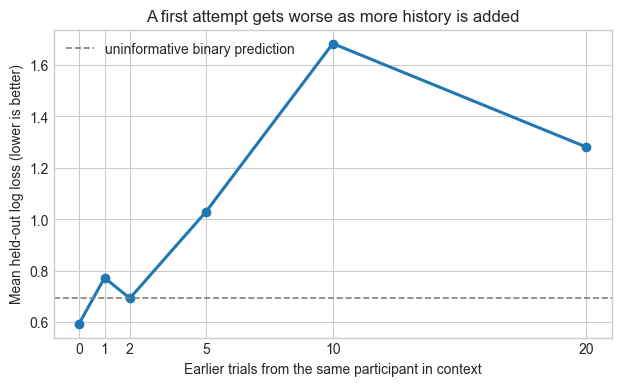

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(curve["history_trials"], curve["log_loss"], marker="o", linewidth=2.2)
ax.axhline(math.log(2), color="gray", linestyle="--", linewidth=1.2, label="uninformative binary prediction")
ax.set(
    title="A first attempt gets worse as more history is added",
    xlabel="Earlier trials from the same participant in context",
    ylabel="Mean held-out log loss (lower is better)",
    xticks=HISTORY_LENGTHS,
)
ax.legend(frameon=False)
plt.show()

### Before interpreting the curve, inspect the examples

In this small first attempt (2 participants x 4 targets), adding history makes
prediction worse. That does not yet mean participant history is useless.

The next question is simpler: **are the labels in the history balanced?**

## 6. An unbalanced history can bias the probability estimate

The first eight history trials contain **6 A and 2 B choices**. The model can
imitate that label frequency instead of learning how the participant evaluates
the options.

We therefore keep the same 40 future choices (**19 A and 21 B**) and compare the
same DeepSeek V4 Pro model under three conditions:

- current trial only;
- eight earlier trials containing 6 A and 2 B choices;
- eight earlier trials resampled to contain 4 A and 4 B choices.

The target choices, model, history length, and score stay fixed. Only the label
balance changes.

In [15]:
BALANCE_PATH = find_file("results/clean_icl_balance_demo/summary.csv")
balance_demo = pd.read_csv(BALANCE_PATH)
balance_demo[[
    "condition", "A_targets", "B_targets", "history_A", "history_B",
    "accuracy", "log_loss", "mean_p_B"
]].round(3)

,condition,A_targets,B_targets,history_A,history_B,accuracy,log_loss,mean_p_B
0,zero_shot,19,21,0,0,0.55,0.675,0.499
1,unbalanced_history,19,21,6,2,0.65,0.715,0.430
2,balanced_history,19,21,4,4,0.60,0.649,0.571


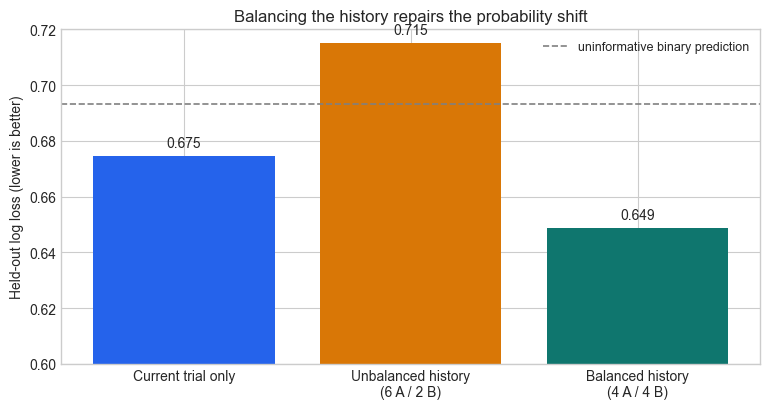

In [16]:
labels = ["Current trial only", "Unbalanced history\n(6 A / 2 B)", "Balanced history\n(4 A / 4 B)"]
order = ["zero_shot", "unbalanced_history", "balanced_history"]
plot_data = balance_demo.set_index("condition").loc[order]

fig, ax = plt.subplots(figsize=(7.8, 4.2))
bars = ax.bar(labels, plot_data["log_loss"], color=["#2563eb", "#d97706", "#0f766e"])
ax.axhline(math.log(2), color="gray", linestyle="--", linewidth=1.2,
           label="uninformative binary prediction")
ax.set(
    title="Balancing the history repairs the probability shift",
    ylabel="Held-out log loss (lower is better)",
    ylim=(0.60, 0.72),
)
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### The learning curve is different for each participant

A single `k=8` comparison hides the important part of the result. We now use
the **same 20 future targets per participant** at every history length and plot
P025 and P026 separately. Both panels share the identical `k=0` predictions.

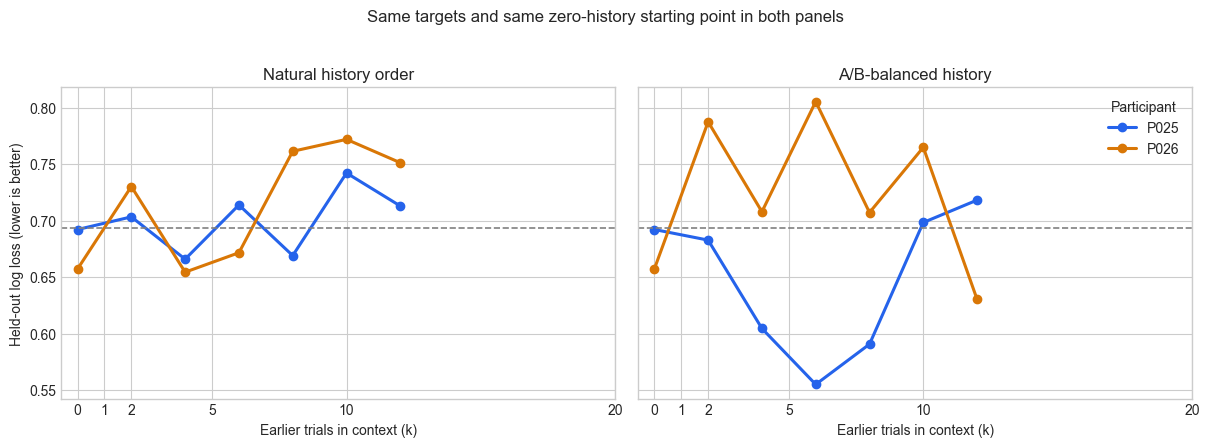

In [17]:
CURVE_PATH = find_file("results/clean_icl_balance_demo/curve_by_participant.csv")
participant_curve = pd.read_csv(CURVE_PATH)

current = participant_curve[participant_curve["history_type"] == "current"]
colors = {"P025": "#2563eb", "P026": "#d97706"}
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.3), sharey=True)

for ax, history_type, title in zip(
    axes,
    ["natural", "balanced"],
    ["Natural history order", "A/B-balanced history"],
):
    for participant in ["P025", "P026"]:
        start = current[current["participant_id"] == participant]
        curve = participant_curve[
            (participant_curve["participant_id"] == participant)
            & (participant_curve["history_type"] == history_type)
        ]
        plot_frame = pd.concat([start, curve]).sort_values("history_k")
        ax.plot(
            plot_frame["history_k"], plot_frame["log_loss"],
            marker="o", linewidth=2.2, label=participant,
            color=colors[participant],
        )
    ax.axhline(math.log(2), color="gray", linestyle="--", linewidth=1.2)
    ax.set(title=title, xlabel="Earlier trials in context (k)", xticks=HISTORY_LENGTHS)

axes[0].set_ylabel("Held-out log loss (lower is better)")
axes[1].legend(title="Participant", frameon=False)
fig.suptitle("Same targets and same zero-history starting point in both panels", y=1.03)
fig.tight_layout()
plt.show()

### Interpretation

The unbalanced history shifts mean `P(B)` down to `0.430` and increases log
loss to `0.715`. Balancing the same number of history examples moves mean
`P(B)` back toward the observed target rate and reduces log loss to `0.649`,
below the current-trial baseline of `0.675`.

Accuracy does not increase in parallel (`0.650` to `0.600`), because several
probabilities move without crossing the 0.5 decision boundary. That is why we
evaluate probabilistic prediction with log loss rather than relying on accuracy
alone.

The remaining lack of a clear personalization gain has at least two plausible
explanations:

- this participant history may not contain a strong, stable individual pattern;
- the current model or prompt may be too weak to extract and use that pattern.

This experiment removes the obvious balance confound, but it does not distinguish
between those explanations.

The participant curves make the uncertainty concrete. With natural history,
neither participant improves reliably as `k` grows. After balancing, P025
improves most around `k=6`, whereas P026 remains noisy and improves only at
`k=12`. Balance therefore removes a confound; it does not guarantee a monotonic
learning curve.

> Balance the demonstrations before asking whether the model learned the participant.

## 7. This is the bridge to "using an LLM as a behavioral model"

The single example and the large experiment use the same ingredients:

| Ingredient | One example | Behavioral-model experiment |
|---|---|---|
| Observation set | one risky-choice trial | trial + `k` earlier choices |
| Model output | token logprobs for A/B | probability for every held-out choice |
| Ground truth | one revealed choice | untouched future choices |
| Score | one log loss | mean log loss, calibration, uncertainty |
| Scientific comparison | none yet | history length, controls, baselines, SFT |

Once the prediction contract is stable, SFT becomes a clean next comparison: train on `P001-P020`, select on `P021-P024`, and evaluate the untouched `P025-P032` targets-with or without same-participant ICL at test time.

## Take-home exercises

1. Run the single live API call and verify that your re-normalized probabilities sum to one.
2. Change `HISTORY_LENGTHS`; identify the best `k` on validation participants, not test participants.
3. Compare `head(k)` with the `k` most recent eligible trials.
4. Replace same-person history with another anonymized participant's history.
5. Shuffle observed choices across history trials while preserving the A/B response rate.
6. Ask whether an apparent ICL gain survives those controls before interpreting it as preference learning.

---

## Optional self-study: session-level supervised fine-tuning

**Not covered live.** This extension follows the central data-format idea used by [Centaur](https://www.nature.com/articles/s41586-025-09215-4): one sequence represents one participant's complete trial-by-trial session, and loss is backpropagated only at human response tokens.

This is different from treating trials as independent training rows:

```text
task + trial 1 -> human response 1
     + trial 2 -> human response 2
     + trial 3 -> human response 3
     ...
```

Earlier observed choices remain in the context. Fine-tuning can therefore learn a **population-level update rule** from `P001-P020`; at test time, that rule can update an **individual-level state** as choices from a new participant accumulate.

We compare base versus adapted model, each with the current trial alone or the participant's complete preceding history. Keep `RUN_OPTIONAL_SFT=False` during class.

In [18]:
RUN_OPTIONAL_SFT = False
SFT_MODEL_NAME = "Qwen/Qwen3-0.6B"  # small enough for a Colab GPU
SFT_EPOCHS = 3
SFT_OUTPUT_DIR = Path("cache/qwen3_0.6b_session_lora")

# Fresh Colab runtime only:
# %pip install -q "transformers>=4.51,<5" "peft>=0.15,<1" "accelerate>=1.4,<2"

### 1. Encode an entire participant session; supervise only A/B

Every training sequence contains 40 trials from one participant. Stimulus, history, and formatting tokens receive label `-100`; only the 40 observed A/B tokens contribute to cross-entropy. This prevents easy shared tokens such as an end marker from dominating the very short behavioral target.

In [19]:
if RUN_OPTIONAL_SFT:
    import torch
    from torch.utils.data import Dataset
    from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments
    from peft import LoraConfig, TaskType, get_peft_model

    if not torch.cuda.is_available():
        raise RuntimeError("Use a Colab or local NVIDIA GPU for this optional section.")

    sft_tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_NAME)
    if sft_tokenizer.pad_token_id is None:
        sft_tokenizer.pad_token = sft_tokenizer.eos_token


    def encode_text(text):
        return sft_tokenizer(text, add_special_tokens=False)["input_ids"]


    def session_instruction():
        messages = [
            {"role": "system", "content": "Predict choices in a risky-choice session."},
            {"role": "user", "content": (
                "Continue this transcript. At every 'Observed choice:' field, "
                "predict exactly A or B. Earlier choices are from the same participant."
            )},
        ]
        return sft_tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
            enable_thinking=False,
        )


    def trial_prefix(row):
        return (
            f"Trial {int(row['trial_index'])}:\n"
            f"Option A: {row['lottery_A']}\n"
            f"Option B: {row['lottery_B']}\n"
            "Observed choice:"
        )


    def encode_session(person):
        input_ids = encode_text(session_instruction())
        labels = [-100] * len(input_ids)
        supervised_tokens = 0
        for _, row in person.sort_values("trial_index").iterrows():
            prefix_ids = encode_text(trial_prefix(row))
            choice_ids = encode_text(" " + str(row["choice"]))
            separator_ids = encode_text("\n\n")
            if len(choice_ids) != 1:
                raise ValueError("This example expects A and B to be one token each.")
            input_ids.extend(prefix_ids)
            labels.extend([-100] * len(prefix_ids))
            input_ids.extend(choice_ids)
            labels.extend(choice_ids)
            supervised_tokens += len(choice_ids)
            input_ids.extend(separator_ids)
            labels.extend([-100] * len(separator_ids))
        assert supervised_tokens == len(person)
        return {
            "input_ids": input_ids,
            "attention_mask": [1] * len(input_ids),
            "labels": labels,
        }


    class ParticipantSessionDataset(Dataset):
        def __init__(self, frame):
            self.examples = [
                encode_session(person)
                for _, person in frame.groupby("participant_id", sort=True)
            ]

        def __len__(self):
            return len(self.examples)

        def __getitem__(self, index):
            return self.examples[index]


    def session_collator(examples):
        rows = len(examples)
        width = max(len(example["input_ids"]) for example in examples)
        input_ids = torch.full(
            (rows, width), sft_tokenizer.pad_token_id, dtype=torch.long
        )
        attention_mask = torch.zeros((rows, width), dtype=torch.long)
        labels = torch.full((rows, width), -100, dtype=torch.long)
        for row_index, example in enumerate(examples):
            size = len(example["input_ids"])
            input_ids[row_index, :size] = torch.tensor(example["input_ids"])
            attention_mask[row_index, :size] = 1
            labels[row_index, :size] = torch.tensor(example["labels"])
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

    sft_train = data[data["participant_id"].isin(TRAIN_PARTICIPANTS)]
    sft_valid = data[data["participant_id"].isin(VALID_PARTICIPANTS)]
    train_sessions = ParticipantSessionDataset(sft_train)
    valid_sessions = ParticipantSessionDataset(sft_valid)
    session_lengths = [len(example["input_ids"]) for example in train_sessions.examples]
    print("Training sessions:", len(train_sessions))
    print("Tokens per session: min/mean/max =",
          min(session_lengths), round(np.mean(session_lengths)), max(session_lengths))
else:
    print("Optional session-level fine-tuning is off.")

Optional session-level fine-tuning is off.


### 2. Attach LoRA weights and train on 20 sessions

The frozen BF16 base model is not quantized. LoRA adds about five million trainable parameters to attention and feed-forward projections. Validation participants are separate; the final test participants remain untouched.

In [20]:
if RUN_OPTIONAL_SFT:
    use_bf16 = bool(torch.cuda.is_bf16_supported())
    dtype = torch.bfloat16 if use_bf16 else torch.float16
    base_model = AutoModelForCausalLM.from_pretrained(
        SFT_MODEL_NAME, torch_dtype=dtype
    ).to("cuda")
    base_model.config.use_cache = False
    sft_model = get_peft_model(
        base_model,
        LoraConfig(
            task_type=TaskType.CAUSAL_LM,
            r=8, lora_alpha=16, lora_dropout=0.05, bias="none",
            target_modules=[
                "q_proj", "k_proj", "v_proj", "o_proj",
                "gate_proj", "up_proj", "down_proj",
            ],
        ),
    )
    sft_model.print_trainable_parameters()

    trainer = Trainer(
        model=sft_model,
        args=TrainingArguments(
            output_dir=str(SFT_OUTPUT_DIR / "trainer"),
            num_train_epochs=SFT_EPOCHS,
            per_device_train_batch_size=1,
            per_device_eval_batch_size=1,
            gradient_accumulation_steps=4,
            learning_rate=2e-4,
            warmup_ratio=0.1,
            logging_steps=1,
            eval_strategy="epoch",
            save_strategy="epoch",
            save_total_limit=1,
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            greater_is_better=False,
            bf16=use_bf16,
            fp16=not use_bf16,
            optim="adamw_torch",
            report_to="none",
            remove_unused_columns=False,
            seed=SEED,
        ),
        train_dataset=train_sessions,
        eval_dataset=valid_sessions,
        data_collator=session_collator,
        processing_class=sft_tokenizer,
    )
    trainer.train()
    trainer.model.save_pretrained(SFT_OUTPUT_DIR / "adapter")
    sft_tokenizer.save_pretrained(SFT_OUTPUT_DIR / "adapter")

### 3. Predict a new participant online

For target trial `t`, the full-history condition includes the new participant's observed trials `1 ... t-1`; the current-only condition removes them. In both cases we sum candidate sequence log probabilities for A and B and re-normalize over the two valid responses.

In [21]:
if RUN_OPTIONAL_SFT:
    from sklearn.metrics import accuracy_score, brier_score_loss, log_loss


    def target_prefix_ids(person, target_trial, include_history):
        ids = encode_text(session_instruction())
        ordered = person.sort_values("trial_index")
        if include_history:
            for _, row in ordered[ordered["trial_index"] < target_trial].iterrows():
                ids.extend(encode_text(trial_prefix(row)))
                ids.extend(encode_text(" " + str(row["choice"])))
                ids.extend(encode_text("\n\n"))
        target_row = ordered[ordered["trial_index"] == target_trial].iloc[0]
        ids.extend(encode_text(trial_prefix(target_row)))
        return ids, target_row


    @torch.inference_mode()
    def candidate_logprob(model, prompt_ids, candidate):
        candidate_ids = encode_text(" " + candidate)
        sequence = torch.tensor([prompt_ids + candidate_ids], device=model.device)
        token_logprobs = model(input_ids=sequence).logits[:, :-1].log_softmax(-1)
        start = len(prompt_ids) - 1
        target_ids = torch.tensor(candidate_ids, device=model.device).unsqueeze(1)
        return float(
            token_logprobs[0, start:start + len(candidate_ids)]
            .gather(1, target_ids).sum().cpu()
        )


    def score_condition(model, include_history, condition):
        rows = []
        for participant in TEST_PARTICIPANTS:
            person = data[data["participant_id"] == participant]
            for target_trial in range(21, 41):
                prompt_ids, target_row = target_prefix_ids(
                    person, target_trial, include_history
                )
                log_a = candidate_logprob(model, prompt_ids, "A")
                log_b = candidate_logprob(model, prompt_ids, "B")
                normalizer = logsumexp([log_a, log_b])
                rows.append({
                    "condition": condition,
                    "participant_id": participant,
                    "trial_index": target_trial,
                    "choice": target_row["choice"],
                    "p_B": math.exp(log_b - normalizer),
                })
        return pd.DataFrame(rows)


    with trainer.model.disable_adapter():
        base_current = score_condition(trainer.model, False, "base_current_only")
        base_history = score_condition(trainer.model, True, "base_full_history")
    sft_current = score_condition(trainer.model, False, "sft_current_only")
    sft_history = score_condition(trainer.model, True, "sft_full_history")


    def summarize(frame):
        y = (frame["choice"] == "B").astype(int)
        p = frame["p_B"].clip(1e-6, 1 - 1e-6)
        return {
            "condition": frame["condition"].iloc[0],
            "accuracy": accuracy_score(y, p >= 0.5),
            "log_loss": log_loss(y, p, labels=[0, 1]),
            "brier": brier_score_loss(y, p),
            "mean_p_B": p.mean(),
        }

    sft_results = pd.DataFrame([
        summarize(frame)
        for frame in [base_current, base_history, sft_current, sft_history]
    ])
    display(sft_results.round(3))

### Local smoke check: what actually happened?

One BF16 run on the bundled public slice produced:

| Condition | Accuracy | Log loss | Mean P(B) |
|---|---:|---:|---:|
| Base, current trial only | 0.544 | 0.677 | 0.489 |
| Base + complete history | 0.444 | 0.749 | 0.429 |
| Session-SFT, current only | 0.488 | 0.692 | 0.563 |
| Session-SFT + complete history | 0.544 | 0.693 | 0.483 |

Session-level SFT changed how the model used history: relative to the corresponding base+history condition, accuracy recovered by 10 percentage points. But it did **not** outperform the best no-history base, and log loss did not improve. A 1.7B size check also failed to produce a reliable full-history gain.

This is a development-scale pipeline check, not confirmatory evidence. With only 20 training sessions and mostly non-overlapping lottery problems, the appropriate conclusion is:

> The code can teach a model to process participant histories, but this public slice is too small to establish a useful individualized behavioral model.

That negative boundary is scientifically useful. Training loss, probability calibration, classification accuracy, and individual-level generalization are separate claims.

### A more informative training unit: one prefix-target decision per example

The session-level version above contains the right information, but the public slice gives it only **20 training sequences**. With batch size 1, gradient accumulation 4, and three epochs, that is only about 15 optimizer updates.

A second implementation keeps the same participant-history logic but changes the optimization unit:

```text
participant trials 1 ... t-1 + current lottery t  ->  current choice t
```

- Each participant contributes 40 progressively longer prefix-target examples.
- Earlier trials include both lotteries and observed choices.
- Only the current A/B token contributes to the loss.
- The split remains population-level: train on 20 participants, validate on 4, test on 8 unseen participants.

This produces 800 training examples and 150 optimizer updates. It is not an individual-specific fine-tune; it trains a population-level rule that may use the history of a new participant at inference time.

In [22]:
# Core data construction for the prefix-target version.
# The complete runnable implementation is scripts/run_prefix_history_sft.py.
if RUN_OPTIONAL_SFT:
    class PrefixTargetDataset(Dataset):
        def __init__(self, frame):
            self.examples = []
            for _, person in frame.groupby("participant_id", sort=True):
                person = person.sort_values("trial_index")
                for target_trial in person["trial_index"].astype(int):
                    prompt_ids, target_row = target_prefix_ids(
                        person, target_trial, include_history=True
                    )
                    answer_ids = encode_text(" " + str(target_row["choice"]))
                    assert len(answer_ids) == 1
                    self.examples.append({
                        "input_ids": prompt_ids + answer_ids,
                        "attention_mask": [1] * (len(prompt_ids) + 1),
                        "labels": [-100] * len(prompt_ids) + answer_ids,
                    })

        def __len__(self):
            return len(self.examples)

        def __getitem__(self, index):
            return self.examples[index]
else:
    print("Prefix-target fine-tuning is optional; no GPU work was started.")


# Memory-safe settings used for the local 24 GB GPU check:
# per_device_train_batch_size=1
# gradient_accumulation_steps=16
# gradient_checkpointing=True
# model.enable_input_require_grads()  # needed with LoRA + checkpointing

Prefix-target fine-tuning is optional; no GPU work was started.


### Prefix-target result: better population calibration, but history still does not help

One local BF16 + LoRA run with Qwen3-0.6B produced:

| Model input | Accuracy | Log loss | Mean P(B) |
|---|---:|---:|---:|
| Base, current trial only | 0.513 | 1.304 | 0.073 |
| Base + complete history | 0.488 | 0.755 | 0.380 |
| Prefix-target SFT, current only | **0.569** | **0.682** | 0.498 |
| Prefix-target SFT + complete history | 0.544 | 0.720 | 0.592 |

Validation loss improved from `0.696` after epoch 1 to `0.682` after epoch 2, then rose to `0.689` after epoch 3. Loading the best checkpoint therefore catches a small amount of late overfitting.

The scientifically useful result is the 2 x 2 comparison:

- Fine-tuning substantially repairs the base model's A/B probability calibration.
- The best condition is nevertheless **fine-tuned + current trial only**.
- Adding the new participant's complete history worsens held-out log loss from `0.682` to `0.720`.

> On this small public slice, supervised fine-tuning learns a population-level response prior and task format more clearly than it learns a useful individual-level update rule.

A shuffled-choice control preserves the same earlier lotteries and the same A/B response count, but permutes which earlier trial received which choice:

| Fine-tuned input | Accuracy | Log loss |
|---|---:|---:|
| Current trial only | **0.569** | **0.682** |
| True participant history | 0.544 | 0.720 |
| Choice-shuffled participant history | 0.538 | 0.748 |

True history is modestly better than shuffled history, so the model is not responding only to the participant's A/B base rate. However, both history conditions remain worse than current-only prediction.

> The present evidence supports weak history sensitivity, not a useful individualized participant model.

The next expansion should add participants or repeated diagnostic task structure—not simply more epochs.